In [6]:
from sklearn import linear_model
from sklearn.metrics import mean_squared_error
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Lasso

In [7]:


insurance_data = pd.read_csv("insurance.csv")

x = insurance_data.drop(columns=["charges"])
y = insurance_data["charges"]

x = pd.get_dummies(x,columns=["region"],drop_first=False,dtype=int)

x["sex"] = x["sex"].map({"female":1,"male":0})
x["smoker"] = x["smoker"].map({"yes":1,"no":0})

x["age_smoker"] = x["age"] * x["smoker"]
x["bmi_smoker"] = x["bmi"] * x["smoker"]


x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)



MSE for alpha=0.001: 20922596.52800621
MSE for alpha=0.1: 20921899.287567742
MSE for alpha=1: 20915761.34772445
MSE for alpha=2: 20909904.88284825
MSE for alpha=5: 20894930.88738715
MSE for alpha=10: 20879460.429074317
MSE for alpha=50: 21137371.396251045
MSE for alpha=100: 22325946.521791253


<Axes: >

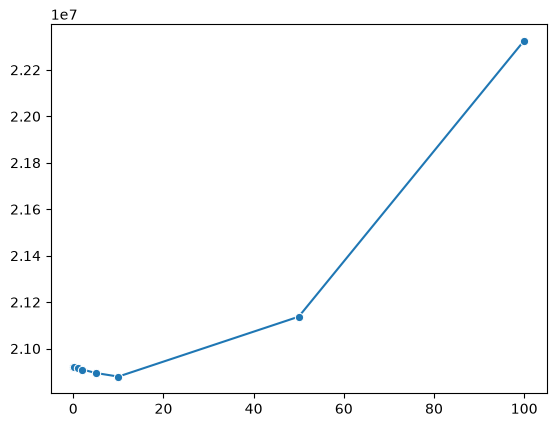

In [14]:
import seaborn as sns
alphas = [0.001, 0.1, 1, 2, 5, 10 , 50, 100]
mses=[]

for a in alphas:
    lasso_model = Lasso(alpha=a)
    lasso_model.fit(x_train,y_train)
    
    y_pred = lasso_model.predict(x_test)
    mse = mean_squared_error(y_test,y_pred)
    print(f"MSE for alpha={a}:",mse)
    mses.append(mse)

sns.lineplot(x=alphas,y=mses,marker="o")

In [23]:
from sklearn.linear_model import LassoCV
from sklearn.metrics import r2_score, mean_squared_error

a = [0.001, 0.1, 1, 2, 5, 10 , 50, 100]

lasso_cv_model = LassoCV(
    alphas = a,
    cv = 5,
    max_iter = 1000,
    random_state = 42
)

lasso_cv_model.fit(x_train,y_train)
print("Best alpha :",lasso_cv_model.alpha_)

y_pred = lasso_cv_model.predict(x_test)
r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
print("mse = ",mse)
print("r2 value =",r2)

Best alpha : 0.001
mse =  20922596.52800621
r2 value = 0.8652317714485488
